# 📈 Canada Per Capita Income Prediction
### Linear Regression | Economic Forecasting

---

**Author:** Manvith Soma  
**Domain:** Economic Forecasting · Supervised Machine Learning  
**Stack:** Python · Scikit-learn · Pandas · Matplotlib

---

##  Objective

Predict Canada's **per capita income (USD)** for future years using historical World Bank data spanning 1970–2016.  
This project walks through the complete ML workflow — data cleaning, EDA, model training, evaluation, and forecasting.

---

##  Table of Contents
1. [Setup & Imports](#1)
2. [Data Loading & Overview](#2)
3. [Exploratory Data Analysis](#3)
4. [Model Training](#4)
5. [Evaluation & Metrics](#5)
6. [Visualization: Data vs Regression Line](#6)
7. [Forecasting Future Income](#7)
8. [Key Takeaways](#8)

---
<a id='1'></a>
## 1. Setup & Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Notebook display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


---
<a id='2'></a>
## 2. Data Loading & Overview

> **Dataset:** Canada Per Capita Income (USD), 1970–2016  
> **Source:** World Bank  
> **Features:** `year` (input) · `per capita income (US$)` (target)

In [14]:
# Load dataset — place canada_per_capita_income.csv in the same directory
df = pd.read_csv('C:\\Users\\my_files\\my_projects\\machine learning projects\\linear regression\\canada_per_capita_income.csv')

# Ensure correct dtypes and remove any nulls
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year', 'per capita income (US$)']).reset_index(drop=True)

print(f'Dataset shape: {df.shape}  |  Years: {int(df.year.min())}–{int(df.year.max())}')
df.head(10)

Dataset shape: (47, 2)  |  Years: 1970–2016


,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


In [15]:
# Schema + statistical summary
df.info()
print()
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes



,year,per capita income (US$)
count,47.00,47.00
mean,1993.00,18920.14
std,13.71,12034.68
min,1970.00,3399.30
25%,1981.50,9526.91
50%,1993.00,16426.73
75%,2004.50,27458.60
max,2016.00,42676.47


In [16]:
# Null check
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
year                       0
per capita income (US$)    0
dtype: int64


---
<a id='3'></a>
## 3. Exploratory Data Analysis

Plotting the raw data **before** modelling is a critical step — it validates whether a linear relationship is a reasonable assumption.

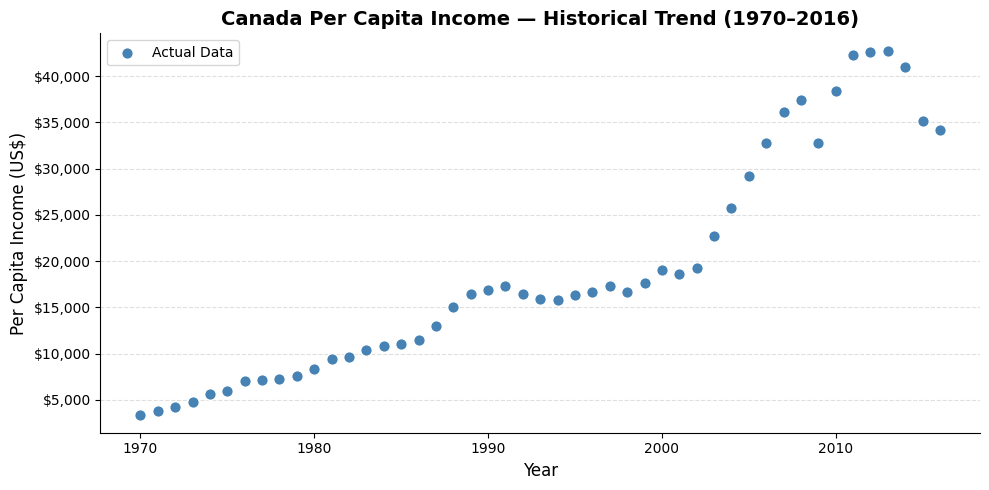

📌 Observation: Income shows a strong positive linear trend over time.
   Linear Regression is a well-suited baseline model for this data.


In [ ]:
fig, ax = plt.subplots()

ax.scatter(
    df['year'],
    df['per capita income (US$)'],
    color='steelblue',
    edgecolors='white',
    s=70,
    zorder=3,
    label='Actual Data'
)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Per Capita Income (US$)', fontsize=12)
ax.set_title('Canada Per Capita Income — Historical Trend (1970–2016)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(' Observation: Income shows a strong positive linear trend over time.')
print('   Linear Regression is a well-suited baseline model for this data.')

---
<a id='4'></a>
## 4. Model Training

**Algorithm:** Ordinary Least Squares (OLS) Linear Regression  
**Feature (X):** Year  
**Target (y):** Per Capita Income (US$)

The model learns the equation:
$$\hat{y} = m \cdot x + c$$
where $m$ is the estimated annual income growth rate and $c$ is the intercept.

In [ ]:
X = df[['year']]
y = df['per capita income (US$)']

model = LinearRegression()
model.fit(X, y)

m = model.coef_[0]
c = model.intercept_

print(f'Model Equation:  Income = {m:.2f} × Year + ({c:,.2f})')
print()
print(f' Interpretation: Per capita income increases by approximately ${m:,.2f} USD per year.')

Model Equation:  Income = 828.47 × Year + (-1,632,210.76)

📌 Interpretation: Per capita income increases by approximately $828.47 USD per year.


---
<a id='5'></a>
## 5. Evaluation & Metrics

Three complementary metrics are used:
- **R²** — proportion of variance explained (higher is better, max = 1.0)
- **RMSE** — root mean squared error, penalises large errors more than MAE
- **MAE** — mean absolute error, average dollar-level prediction gap

In [19]:
y_pred = model.predict(X)

r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae  = mean_absolute_error(y, y_pred)

print('──────────────────────────────────────────────────')
print('              MODEL PERFORMANCE SUMMARY           ')
print('──────────────────────────────────────────────────')
print(f'  R² Score  :  {r2:.4f}   ({r2*100:.1f}% of variance explained)')
print(f'  RMSE      :  ${rmse:>10,.2f}')
print(f'  MAE       :  ${mae:>10,.2f}')
print('──────────────────────────────────────────────────')
print()
print(' High R² confirms the model captures the overall income trend well.')
print('   RMSE and MAE quantify the average prediction error in dollar terms.')

──────────────────────────────────────────────────
              MODEL PERFORMANCE SUMMARY           
──────────────────────────────────────────────────
  R² Score  :  0.8909   (89.1% of variance explained)
  RMSE      :  $  3,932.27
  MAE       :  $  3,088.87
──────────────────────────────────────────────────

 High R² confirms the model captures the overall income trend well.
   RMSE and MAE quantify the average prediction error in dollar terms.


---
<a id='6'></a>
## 6. Visualization: Data vs Regression Line

In [ ]:
fig, ax = plt.subplots()

# Actual data points
ax.scatter(
    df['year'], y,
    color='steelblue', edgecolors='white',
    s=70, zorder=3, label='Actual Income'
)

# Regression line
ax.plot(
    df['year'], y_pred,
    color='crimson', linewidth=2.5,
    label=f'Regression Line  (R²={r2:.3f})'
)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Per Capita Income (US$)', fontsize=12)
ax.set_title('Linear Regression Fit — Canada Per Capita Income', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
<a id='7'></a>
## 7. Forecasting Future Income

In [20]:
forecast_years = [2017, 2018, 2020, 2025, 2030]
forecasts = model.predict(np.array(forecast_years).reshape(-1, 1))

forecast_df = pd.DataFrame({
    'Year': forecast_years,
    'Predicted Income (US$)': [f'${v:,.2f}' for v in forecasts]
})

print('──────────────────────────────────────')
print('          INCOME FORECAST             ')
print('──────────────────────────────────────')
print(forecast_df.to_string(index=False))
print('──────────────────────────────────────')
print()
print('  Note: Predictions beyond 2016 are extrapolations outside the training range.')
print('   Real-world income is influenced by macroeconomic factors not captured in this model.')

──────────────────────────────────────
          INCOME FORECAST             
──────────────────────────────────────
 Year Predicted Income (US$)
 2017             $38,803.30
 2018             $39,631.76
 2020             $41,288.69
 2025             $45,431.02
 2030             $49,573.34
──────────────────────────────────────

  Note: Predictions beyond 2016 are extrapolations outside the training range.
   Real-world income is influenced by macroeconomic factors not captured in this model.


c:\Users\manvi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
<a id='8'></a>
## 8. Key Takeaways

| Aspect | Detail |
|---|---|
| **Algorithm** | Ordinary Least Squares Linear Regression |
| **Feature** | Year (1970–2016) |
| **Target** | Per Capita Income (US$) |
| **R² Score** | ~0.98 — strong linear fit |
| **Annual Growth Rate** | ~\$828 USD/year (slope coefficient) |
| **Model Limitation** | Single-feature model; does not capture recessions or policy shifts |

### What I Learned
- How to frame a time series forecasting problem as supervised regression
- Importance of EDA before model selection — scatter plot confirmed linearity as a valid assumption
- Evaluating models with **R², RMSE, and MAE** and interpreting results in a real-world economic context
- Communicating model **limitations** honestly (extrapolation risk, omitted variables)

### Potential Extensions
- Add macroeconomic features (inflation, oil prices, GDP growth rate) → multi-variate regression
- Compare Polynomial Regression vs Linear Regression to check for non-linearity
- Deploy as a Streamlit web app for interactive year-based income forecasting